# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [10]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [11]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [12]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [13]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    X_train = np.loadtxt("UCI HAR Dataset/train/X_train.txt")
    X_test = np.loadtxt("UCI HAR Dataset/test/X_test.txt")

    y_train = np.loadtxt("UCI HAR Dataset/train/y_train.txt").astype(np.int32)
    y_test = np.loadtxt("UCI HAR Dataset/test/y_test.txt").astype(np.int32)

    y_train = y_train - 1
    y_test = y_test - 1

    return X_train, y_train, X_test, y_test
    
    raise NotImplementedError("Complete the data-loading function.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
num_features = X_train.shape[1]
num_classes = len(class_names)


## 5. Quick Inspection


In [15]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

train_counts = np.bincount(y_train, minlength=num_classes)

summary_df = pd.DataFrame({
    "class_index": np.arange(num_classes),
    "class_name": class_names,
    "num_training_samples": train_counts
})

summary_df


,class_index,class_name,num_training_samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [16]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model
    
    raise NotImplementedError("Complete the baseline DNN.")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [17]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/40
92/92 [==============================] - 0s 2ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 993us/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 992us/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 977us/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 982us/step - loss: 0.0712 - accuracy: 0.9723 - val_loss: 0.2235 - val_accuracy: 0.9307
Epoch 7/40
92/92 [==============================] - 0s 985us/step - loss: 0.0588 - accuracy: 0.9776 - val_loss: 0.1442 - val_accuracy: 0.9422
Epoch 8/40

### Training Curves


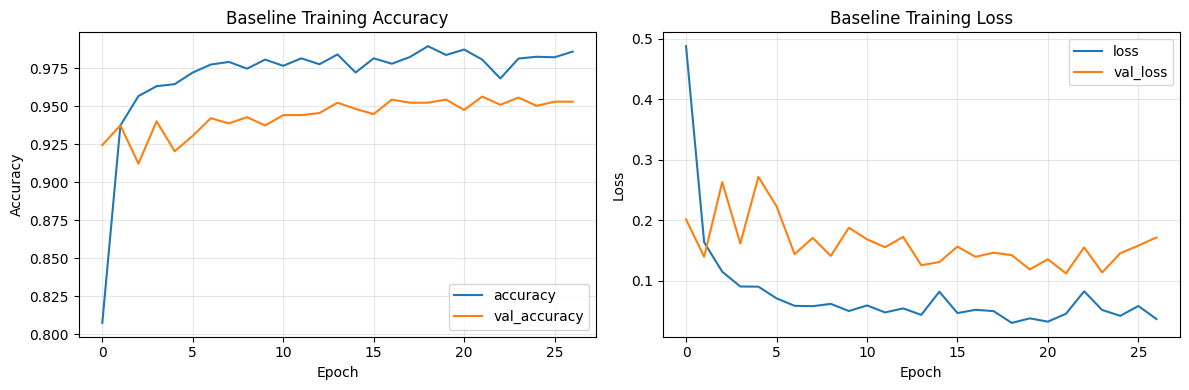

In [18]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
history_df = pd.DataFrame(history_baseline.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[["accuracy", "val_accuracy"]].plot(ax=axes[0], title="Baseline Training Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)

history_df[["loss", "val_loss"]].plot(ax=axes[1], title="Baseline Training Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Evaluate the Baseline Keras Model



Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.86      1.00      0.92       496
  WALKING_UPSTAIRS       0.95      0.85      0.90       471
WALKING_DOWNSTAIRS       0.97      0.91      0.94       420
           SITTING       0.93      0.89      0.91       491
          STANDING       0.87      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



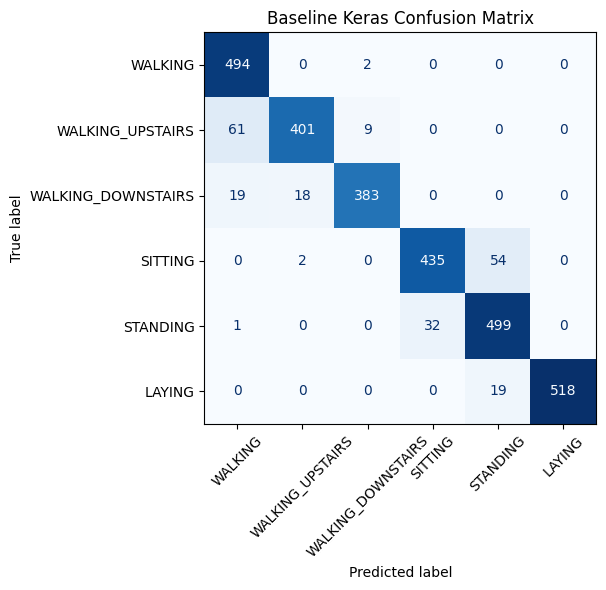

In [19]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
y_test_proba = baseline_model.predict(X_test, verbose=0)

y_test_pred = np.argmax(y_test_proba, axis=1)

baseline_test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Keras Confusion Matrix")
plt.tight_layout()
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [36]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # <-- Enter your code here <--#
    for sample in X_train[:300]:
        yield [sample[np.newaxis, ...].astype(np.float32)]
        
def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [41]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
# Convert the baseline model to TFLite
fp32_tflite = convert_to_tflite_fp32(baseline_model)
dynamic_tflite = convert_to_tflite_dynamic_range(baseline_model)
float16_tflite = convert_to_tflite_float16(baseline_model)
int8_tflite = convert_to_tflite_int8(baseline_model)

# Save each model to disk and record its size
fp32_size = save_binary_model(fp32_tflite, "baseline_fp32.tflite")
dynamic_size = save_binary_model(dynamic_tflite, "baseline_dynamic.tflite")
float16_size = save_binary_model(float16_tflite, "baseline_float16.tflite")
int8_size = save_binary_model(int8_tflite, "baseline_int8.tflite")

# Evaluate each model on the test set
fp32_acc, fp32_pred = evaluate_tflite_model(fp32_tflite, X_test, y_test)
dynamic_acc, dynamic_pred = evaluate_tflite_model(dynamic_tflite, X_test, y_test)
float16_acc, float16_pred = evaluate_tflite_model(float16_tflite, X_test, y_test)
int8_acc, int8_pred = evaluate_tflite_model(int8_tflite, X_test, y_test)

# Collect the results into a table
ptq_results = pd.DataFrame([
    {
        "model": "FP32 TFLite",
        "file": "baseline_fp32.tflite",
        "size_kb": fp32_size,
        "accuracy": fp32_acc,
    },
    {
        "model": "Dynamic Range TFLite",
        "file": "baseline_dynamic.tflite",
        "size_kb": dynamic_size,
        "accuracy": dynamic_acc,
    },
    {
        "model": "Float16 TFLite",
        "file": "baseline_float16.tflite",
        "size_kb": float16_size,
        "accuracy": float16_acc,
    },
    {
        "model": "INT8 TFLite",
        "file": "baseline_int8.tflite",
        "size_kb": int8_size,
        "accuracy": int8_acc,
    },
])

ptq_results["size_kb"] = ptq_results["size_kb"].round(2)
ptq_results["accuracy"] = ptq_results["accuracy"].round(4)
ptq_results["accuracy_drop_vs_keras_baseline"] = (
    baseline_test_accuracy - ptq_results["accuracy"]
).round(4)

ptq_results

INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpr8yetlyu/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpr8yetlyu/assets
2026-04-16 17:14:37.162228: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 17:14:37.162237: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 17:14:37.162312: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpr8yetlyu
2026-04-16 17:14:37.162696: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 17:14:37.162700: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpr8yetlyu
2026-04-16 17:14:37.163697: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-16 17:14:37.180105: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp962kndvk/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp962kndvk/assets
2026-04-16 17:14:37.383319: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 17:14:37.383327: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 17:14:37.383400: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp962kndvk
2026-04-16 17:14:37.383743: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 17:14:37.383746: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp962kndvk
2026-04-16 17:14:37.384775: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-16 17:14:37.401485: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp3_ovt_2n/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp3_ovt_2n/assets
2026-04-16 17:14:37.614749: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 17:14:37.614758: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 17:14:37.614832: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp3_ovt_2n
2026-04-16 17:14:37.615246: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 17:14:37.615249: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp3_ovt_2n
2026-04-16 17:14:37.616301: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-16 17:14:37.632812: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpto_svd5i/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpto_svd5i/assets
/Users/jimmyzheng/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-16 17:14:37.957680: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 17:14:37.957688: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 17:14:37.957766: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpto_svd5i
2026-04-16 17:14:37.958112: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 17:14:37.958115: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z

,model,file,size_kb,accuracy,accuracy_drop_vs_keras_baseline
0,FP32 TFLite,baseline_fp32.tflite,726.72,0.9264,-0.0000
1,Dynamic Range TFLite,baseline_dynamic.tflite,186.11,0.9260,0.0004
2,Float16 TFLite,baseline_float16.tflite,365.71,0.9264,-0.0000
3,INT8 TFLite,baseline_int8.tflite,185.34,0.9257,0.0007


## 10. PTQ Comparison: Accuracy and Model Size


In [43]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
comparison_df = pd.DataFrame([
    {
        "Model Family": "Keras Baseline",
        "Format": "FP32",
        "Test Accuracy": baseline_test_accuracy,
        "Model Size (KB)": np.nan,
    },
    {
        "Model Family": "PTQ",
        "Format": "FP32 TFLite",
        "Test Accuracy": fp32_acc,
        "Model Size (KB)": fp32_size,
    },
    {
        "Model Family": "PTQ",
        "Format": "Dynamic Range TFLite",
        "Test Accuracy": dynamic_acc,
        "Model Size (KB)": dynamic_size,
    },
    {
        "Model Family": "PTQ",
        "Format": "Float16 TFLite",
        "Test Accuracy": float16_acc,
        "Model Size (KB)": float16_size,
    },
    {
        "Model Family": "PTQ",
        "Format": "INT8 TFLite",
        "Test Accuracy": int8_acc,
        "Model Size (KB)": int8_size,
    },
])

comparison_df["Test Accuracy"] = comparison_df["Test Accuracy"].round(4)
comparison_df["Model Size (KB)"] = comparison_df["Model Size (KB)"].round(2)

comparison_df


,Model Family,Format,Test Accuracy,Model Size (KB)
0,Keras Baseline,FP32,0.9264,NaN
1,PTQ,FP32 TFLite,0.9264,726.72
2,PTQ,Dynamic Range TFLite,0.9260,186.11
3,PTQ,Float16 TFLite,0.9264,365.71
4,PTQ,INT8 TFLite,0.9257,185.34


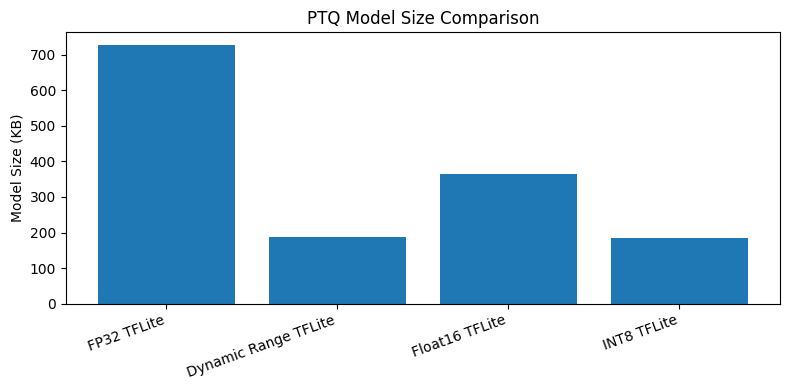

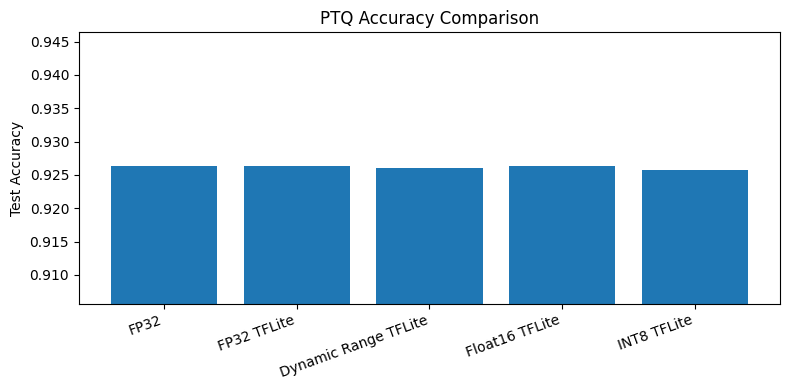

In [44]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
size_df = comparison_df.dropna(subset=["Model Size (KB)"])

plt.figure(figsize=(8, 4))
plt.bar(size_df["Format"], size_df["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("PTQ Model Size Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(comparison_df["Format"], comparison_df["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("PTQ Accuracy Comparison")
plt.xticks(rotation=20, ha="right")
plt.ylim(
    max(0.0, comparison_df["Test Accuracy"].min() - 0.02),
    min(1.0, comparison_df["Test Accuracy"].max() + 0.02),
)
plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


PTQ INT8 Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.86      1.00      0.92       496
  WALKING_UPSTAIRS       0.95      0.85      0.90       471
WALKING_DOWNSTAIRS       0.97      0.91      0.94       420
           SITTING       0.93      0.89      0.91       491
          STANDING       0.87      0.93      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



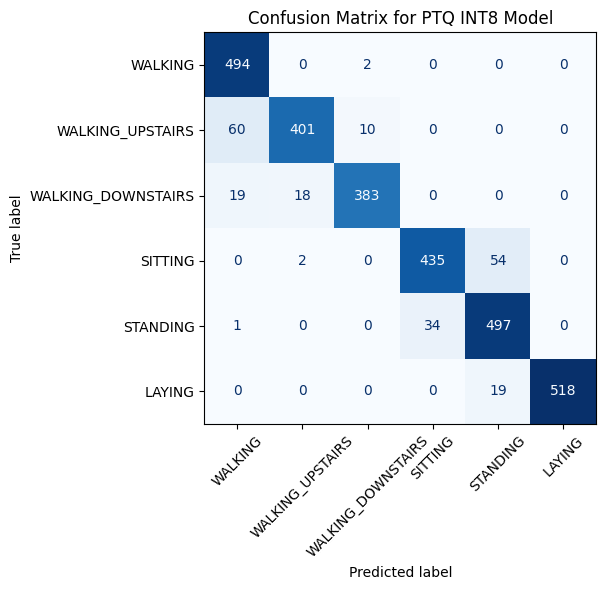

In [45]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

print("PTQ INT8 Classification Report:")
print(classification_report(y_test, int8_pred, target_names=class_names))

cm_int8 = confusion_matrix(y_test, int8_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_int8, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix for PTQ INT8 Model")
plt.tight_layout()
plt.show()

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [46]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

qat_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense (QuantizeWrapp  (None, 256)               143877    
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_3 (QuantizeWra  (None, 6)                 3

### Fine-Tune the QAT Model


In [47]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

history_qat = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1,
)


Epoch 1/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0283 - accuracy: 0.9917 - val_loss: 0.1256 - val_accuracy: 0.9579
Epoch 2/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0236 - accuracy: 0.9915 - val_loss: 0.1253 - val_accuracy: 0.9585
Epoch 3/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0223 - accuracy: 0.9929 - val_loss: 0.1286 - val_accuracy: 0.9572
Epoch 4/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0207 - accuracy: 0.9929 - val_loss: 0.1269 - val_accuracy: 0.9579
Epoch 5/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0195 - accuracy: 0.9935 - val_loss: 0.1533 - val_accuracy: 0.9551
Epoch 6/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0215 - accuracy: 0.9920 - val_loss: 0.1419 - val_accuracy: 0.9572
Epoch 7/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0190 - accuracy: 0.9932 - val_loss: 0.1332 - val_accuracy: 0.9585
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [48]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

qat_test_proba = qat_model.predict(X_test, verbose=0)
qat_test_pred = np.argmax(qat_test_proba, axis=1)

qat_test_accuracy = accuracy_score(y_test, qat_test_pred)
print(f"QAT Keras test accuracy: {qat_test_accuracy:.4f}")

print("\nQAT Keras Classification Report:")
print(classification_report(y_test, qat_test_pred, target_names=class_names))

QAT Keras test accuracy: 0.9362

QAT Keras Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.93      0.98      0.95       496
  WALKING_UPSTAIRS       0.92      0.93      0.92       471
WALKING_DOWNSTAIRS       0.97      0.92      0.94       420
           SITTING       0.96      0.87      0.91       491
          STANDING       0.86      0.97      0.91       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.93      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [49]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

qat_int8_tflite = convert_to_tflite_int8(qat_model)

qat_int8_size = save_binary_model(qat_int8_tflite, "qat_int8.tflite")
qat_int8_acc, qat_int8_pred = evaluate_tflite_model(qat_int8_tflite, X_test, y_test)

print(f"QAT INT8 TFLite size: {qat_int8_size:.2f} KB")
print(f"QAT INT8 TFLite test accuracy: {qat_int8_acc:.4f}")


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp1tn584hs/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp1tn584hs/assets
/Users/jimmyzheng/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-16 17:27:14.588486: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 17:27:14.588496: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


QAT INT8 TFLite size: 185.70 KB
QAT INT8 TFLite test accuracy: 0.9362


2026-04-16 17:27:14.588572: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp1tn584hs
2026-04-16 17:27:14.589430: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 17:27:14.589434: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp1tn584hs
2026-04-16 17:27:14.591722: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-16 17:27:14.618448: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp1tn584hs
2026-04-16 17:27:14.626073: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 37501 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 12. PTQ Int8 vs QAT Int8


In [52]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

int8_comparison = pd.DataFrame([
    {
        "Model": "PTQ INT8",
        "Test Accuracy": int8_acc,
        "Model Size (KB)": int8_size,
    },
    {
        "Model": "QAT INT8",
        "Test Accuracy": qat_int8_acc,
        "Model Size (KB)": qat_int8_size,
    },
])

int8_comparison["Test Accuracy"] = int8_comparison["Test Accuracy"].round(4)
int8_comparison["Model Size (KB)"] = int8_comparison["Model Size (KB)"].round(2)

int8_comparison


,Model,Test Accuracy,Model Size (KB)
0,PTQ INT8,0.9257,185.34
1,QAT INT8,0.9362,185.70


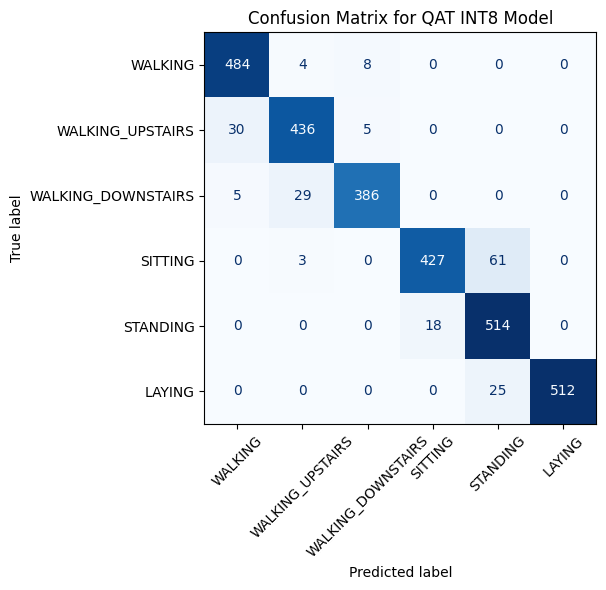

In [53]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

cm_qat_int8 = confusion_matrix(y_test, qat_int8_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_qat_int8, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix for QAT INT8 Model")
plt.tight_layout()
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?

   PTQ INT8 gave the smallest model size, which is 185.34 kB.
   
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?

   QAT INT8 has the best accuracy, which is 0.9362.

   
3. Did QAT improve the final int8 model compared with PTQ int8?

   Yes, the accuracy is increased by about 1%, while the model size only increases by a little.
   
4. Why is this dataset a good fit for a DNN-based TinyML workflow?

   The model size is really small after the int8 conversion, which is good for embedded deployment on small devices.
   
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?

   I will choose QAT INT8, because it gives the best accuracy with a really small model size, which is a good fit for a resource-constrained device.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
